**Goal:** revisit the coqui detector from L02 with a classifier that does not just
answer -- it tells you how sure it is. Pairs with the concept note
[Classification with Logistic Regression](l04_concept_logistic_regression.qmd).

> **Previously:** L03 -- The Supervised Learning Problem and Linear Regression  |  **Next:** L05 -- Linear Models for Classification

> This page is the read-only view. To run the lab, open the notebook
> (`l04_lab_logistic_regression.ipynb`) -- in Colab via the badge on the concept page,
> or locally.

## Scenario

The biodiversity team from L02 is back with a complaint. The kNN detector labels
every call with the same flat certainty -- but the biologists triage by confidence: a
detection at 93% gets filed, one at 52% gets a human listen. They need probabilities.

Same data as L02: two frog species, two acoustic features per call (the pitch of the
"co" note and of the "qui" note, in kHz). Synthetic, fixed seed, fictionalized but
plausible values -- identical numbers for everyone.

## Setup

The setup is **two cells** (the pattern every lab in the course uses). Run them top to
bottom. The first only installs; the second imports, seeds the random number generator,
and builds the data -- so when you re-run imports while experimenting, you do not re-install.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a
# no-op there; it models the install step. Locally the uv equivalent is the comment below.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)          # the L02 generator, verbatim
n = 150                                  # calls per species

calls = pd.DataFrame({
    "co_khz":  np.concatenate([rng.normal(1.15, 0.18, n), rng.normal(1.45, 0.18, n)]),
    "qui_khz": np.concatenate([rng.normal(2.05, 0.25, n), rng.normal(2.45, 0.25, n)]),
    "species": ["coqui"] * n + ["portoricensis"] * n,
})

Hold out a test set before any model, exactly as in L02 -- same seed, same split, so
every accuracy here is directly comparable with the 0.840 our kNN scored there:

In [3]:
from sklearn.model_selection import train_test_split

X = calls[["co_khz", "qui_khz"]]
y = calls["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=11, stratify=y)
print(len(X_train), "training calls /", len(X_test), "test calls")

225 training calls / 75 test calls


~~~text
225 training calls / 75 test calls
~~~

## Step 1: Labels vs Probabilities

### Naive approach: a classifier that only answers

First, re-earn L02's number. kNN votes among neighbors and hands you the winning
label -- nothing else:

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
print(f"kNN test accuracy: {knn.score(X_test, y_test):.3f}")

kNN test accuracy: 0.840


~~~text
kNN test accuracy: 0.840
~~~

### Better approach: a classifier that grades its own certainty

Logistic regression learns one weight per feature plus an intercept, squashes the
weighted sum through the sigmoid, and outputs a *probability*:

In [5]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(X_train, y_train)
print(f"logistic test accuracy: {logreg.score(X_test, y_test):.3f}")
print("class order:", logreg.classes_)

logistic test accuracy: 0.853
class order: ['coqui' 'portoricensis']


~~~text
logistic test accuracy: 0.853
class order: ['coqui' 'portoricensis']
~~~

Slightly better than kNN on the same split -- but the accuracy is not the headline.
The headline is `predict_proba`. The concept note said the 0.5-probability threshold
draws a *line* through feature space; let's see it:

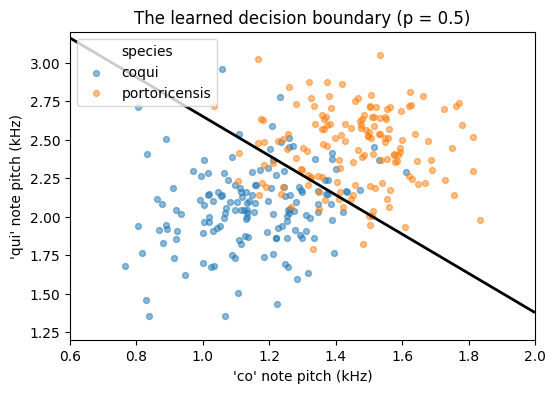

In [6]:
xx, yy = np.meshgrid(np.linspace(0.6, 2.0, 200), np.linspace(1.2, 3.2, 200))
grid = pd.DataFrame({"co_khz": xx.ravel(), "qui_khz": yy.ravel()})
p_grid = logreg.predict_proba(grid)[:, 1].reshape(xx.shape)   # column 1 = portoricensis

fig, ax = plt.subplots(figsize=(6, 4))
for name, group in calls.groupby("species"):
    ax.scatter(group["co_khz"], group["qui_khz"], label=name, alpha=0.5, s=18)
ax.contour(xx, yy, p_grid, levels=[0.5], linewidths=2, colors="black")
ax.set_xlabel("'co' note pitch (kHz)")
ax.set_ylabel("'qui' note pitch (kHz)")
ax.legend(title="species")
ax.set_title("The learned decision boundary (p = 0.5)")
plt.show()

The black line is where the model says 50/50 -- a straight line, because logistic
regression is a linear classifier. Everything above-right of it gets called
*portoricensis*; below-left, *coqui*. Now ask the model which test calls it found
hardest -- the ones with probability closest to 0.5:

In [7]:
proba = logreg.predict_proba(X_test)
p_port = proba[:, 1]                       # follows the class order printed above

uncertain = np.abs(p_port - 0.5).argsort()[:3]
report = X_test.iloc[uncertain].copy()
report["p_portoricensis"] = p_port[uncertain].round(3)
report["true_species"] = y_test.iloc[uncertain].values
print(report.round(3).to_string())

     co_khz  qui_khz  p_portoricensis   true_species
291   1.500    2.003            0.492  portoricensis
243   1.410    2.113            0.488  portoricensis
226   1.324    2.254            0.515  portoricensis


~~~text
     co_khz  qui_khz  p_portoricensis   true_species
291   1.500    2.003            0.492  portoricensis
243   1.410    2.113            0.488  portoricensis
226   1.324    2.254            0.515  portoricensis
~~~

These three calls are coin flips to the model -- and if you locate them on the
scatter, they sit right against the black line. This is exactly the triage list the
field team asked for: `predict` would have answered for all three with a straight
face; `predict_proba` flags them for a human ear.

## Step 2: Three Species at Once -- completion problem

Softmax regression is the same idea with one score per class: exponentiate,
normalize, predict the argmax. scikit-learn's `LogisticRegression` does it
automatically when the labels have more than two classes. We use the classic iris
dataset (bundled with scikit-learn -- nothing to download): 150 flowers, 4
measurements, 3 species. Complete the marked lines:

In [8]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = pd.Series(iris.target_names[iris.target], name="species")

# Uncomment and complete the marked lines:
# Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_iris, y_iris, test_size=0.25,
#                                                         random_state=11, stratify=y_iris)
# softmax = LogisticRegression(max_iter=1000).fit(____, ____)    # fit on the TRAINING data
# print(f"iris test accuracy: {softmax.score(____, ____):.3f}")  # score on the TEST data
# probs = softmax.predict_proba(Xi_test)
# least_confident = probs.max(axis=1).argmin()
# most_confident = probs.max(axis=1).argmax()
# print("class order:", softmax.classes_)
# print("least confident test flower:", np.round(probs[least_confident], 3),
#       "true:", yi_test.iloc[least_confident])
# print("most confident test flower:", np.round(probs[most_confident], 3),
#       "true:", yi_test.iloc[most_confident])

<details><summary>Expected Output</summary>

~~~text
iris test accuracy: 0.974
class order: ['setosa' 'versicolor' 'virginica']
least confident test flower: [0.001 0.334 0.665] true: virginica
most confident test flower: [0.    0.004 0.996] true: virginica
~~~

Near-perfect accuracy -- iris is an easy dataset -- and still the probabilities earn
their keep. Contrast the two flowers: the most confident one is practically a
declaration, [0, 0.004, 0.996], while the least confident gets [0.001, 0.334, 0.665]
-- sure it is not *setosa*, torn two-to-one between *versicolor* and *virginica*,
two species that genuinely overlap. Three numbers that sum to 1, one per class: that
is softmax.
</details>

## Your Turn

### Exercise 1 -- Move the threshold

The field team only wants to file *portoricensis* detections they can trust, so they
propose acting only when the probability is at least 0.8. How many test calls get the
label at threshold 0.5 vs 0.8, and what happens to overall accuracy? Who would want
this trade?

**Hint:** reuse `p_port` from Step 1; compare `(p_port >= 0.5).sum()` with `(p_port >= 0.8).sum()`, then compute accuracy with labels from `np.where(p_port >= 0.8, "portoricensis", "coqui")`.

In [9]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
threshold 0.5: 39 of 75 test calls labeled portoricensis
threshold 0.8: 18 of 75 test calls labeled portoricensis
accuracy at threshold 0.8: 0.733
~~~

Raising the bar more than halves the detections (39 to 18) and *lowers* overall
accuracy -- many true portoricensis calls now get called coqui. But the 18 that
remain are high-confidence detections, which is what the team asked for: fewer
answers, more trustworthy ones. The right threshold depends on which mistake costs
more -- an idea Unit III turns into proper machinery.
</details>

### Exercise 2 -- The most confident mistake

Probabilities are estimates, not guarantees. Find the test call the model gets wrong
with the *highest* confidence.

**Hint:** `pred = logreg.predict(X_test)`; among indices where `pred != y_test.values`, find the one with the largest `proba.max(axis=1)`.

In [10]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
most confident miss: predicted coqui with p=0.726, true portoricensis
~~~

The model was 73% sure -- and wrong. (Eleven of the 75 test calls are misclassified
in all; this is simply the loudest one.) A probability tells you the model's degree
of belief given what it learned, not the truth. Treat 0.726 as "usually right, worth
spot-checking", never as a promise.
</details>

## Summary

- kNN hands you a label; logistic regression hands you a **probability** -- and on
  the same split it also edged kNN, 0.853 vs 0.840.
- The 0.5-probability threshold is a straight **decision boundary** in feature space;
  calls with probability near 0.5 sit near that line and deserve human review.
- The threshold is a dial, not a constant: raising it trades how many detections you
  make against how trustworthy each one is.
- Probabilities are the model's beliefs, not guarantees -- its most confident
  mistake was at 73%.
- Next (L05): the unifying view of linear classifiers -- separating hyperplanes and
  the **Perceptron**, multiclass strategies, and the bridge to the generative models
  (L06-L07) that learn what each class *looks like*.